(sec:nn)=
# Neural networks

## Components and structure

Neural networks are built as layers of neurons (also referred to as  perceptrons). Every neuron has an associated activation level (a real number) representing its state. The activation level of neuron $n$ in layer $L$ is denoted $a^{(L)}_n$.

The first and last layers are referred to as the *input* and *output* layers, respectively, and those in between are called *hidden* layers.

![Neural Network](../images/neural_network.svg)

The input layer receives input data; hidden layers transform the data; and the output layer provides the results upon which model predictions are made.

## Forward propagation

The input level apart, activation levels in a given level, say $L$, are determined from those in the previous layer by use of weights that are collected in a matrix $\boldsymbol{W}^{(L)}$ and biases that are collected in a vector $\boldsymbol{b}^{(L)}$. 

The organization of the weights into matrix form is illustrated in the figure above. The neuron number in layer $L$ becomes the row index and the neuron number in layer $L-1$ becomes the column index.

A layer is referred to as *linear* if the weights and biases are applied in a linear transformation

$$
\boldsymbol{a}^{(L)} = f(\boldsymbol{W}^{(L)} \boldsymbol{a}^{(L-1)} 
+ \boldsymbol{b}^{(L)})
$$

As indicated, to get the final activation levels also involves the elementwise operation of a  (typically) nonlinear activation function, $f$.

### Activation functions

Several activation functions are available in the sklearn library.

For the hidden layers, users can choose from the following functions. 

| Activation | Formula          | Range     | Typical use        |
|:-----------|:-----------------|:----------|:-------------------|
| identity   | x               | (-∞, ∞)   | rarely used        |
| logistic   | sigmoid         | (0, 1)    | older models       |
| tanh       | tanh            | (-1, 1)   | better than sigmoid|
| relu       | max(0, x)       | [0, ∞)    | default/recommended|

The output layer uses a predefined activation suited to the classification task.

| Location        | Activation options                          |
|:----------------|:--------------------------------------------|
| Hidden layers   | identity, logistic, tanh, relu              |
| Output layer    | logistic (binary), softmax (multiclass)     |

## Sklearn libary import

We will make use of the [sklearn](#sec:sklearn) library to build, train, and run multilayer perceptron (MLP) models.

In [1]:
import sklearn

## Data preparation

### Import data

Let us load the breast cancer data set, containing 569 data samples with 30 features. The target data is equal to 0 (malignant) or 1 (benign).

In [2]:
cancer = sklearn.datasets.load_breast_cancer()

X, y = cancer["data"], cancer["target"]

In [3]:
# Show data as a Pandas dataframe
import numpy as np
import pandas as pd

df = pd.DataFrame(
    np.column_stack((X, y)),
    columns=np.append(cancer["feature_names"], ["target"]),
)

df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0.0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0.0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0.0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0.0


In [4]:
# Count number of benign and malignant tumors
number_benign = df[df["target"] == 1.0].shape[0]
number_malign = df[df["target"] == 0.0].shape[0]

print("Number benign   :", number_benign)
print("Number malignant:", number_malign)
print(21 * "-")
print("Total number    :", df.shape[0])

Number benign   : 357
Number malignant: 212
---------------------
Total number    : 569


### Split data into training, validation, and test sets

Data are split into different categories.

| Dataset | Purpose |
|:--------|:--------|
| Training data | Learn model parameters |
| Validation data | Tune model (hyperparameters, topology, etc.) |
| Test data | Final, unbiased evaluation |

We will omit the category of validation data, and split the data into 80% training and 20% test data.

In [5]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
)

With `stratify` activated, the training and test sets will get the same proportion of data classes (in this case malignant/benign).

### Scale transformation of data

We scale all input features of the training data so they have mean 0 and standard deviation 1, which is essential for stable and efficient training of neural networks. The scaling parameters $\mu$ and $\sigma$ are computed for the training data and applied to both sets as to avoid using any information of the test set.

The transformation reads

$$
X_\mathrm{scaled} = \frac{X - \mu}{\sigma}
$$

In [6]:
scaler = sklearn.preprocessing.StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

This scaling results in the model putting equal focus on all features in the data set. 

After the transformation, the training data becomes equal to

In [7]:
# Scale-transformed data
df_train_scaled = pd.DataFrame(
    np.column_stack((X_train_scaled, y_train)),
    columns=np.append(cancer["feature_names"], ["target"]),
)

df_train_scaled

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,0.394506,1.059563,0.508190,0.236444,1.566710,1.623947,1.468458,0.980516,0.000712,1.156736,...,1.699859,0.334995,0.070353,1.808060,1.622461,1.568233,1.592375,0.184879,1.336849,0.0
1,-0.172197,-0.102099,-0.154962,-0.272486,0.690237,0.216948,-0.026525,0.145379,-0.002971,-0.261369,...,0.239716,-0.294651,-0.360496,0.474416,0.031059,0.358640,0.484086,-0.373240,-0.389996,1.0
2,-0.175103,-1.520888,-0.256758,-0.248685,-1.581524,-1.311874,-1.085795,-1.168678,-1.627089,-1.312236,...,-1.401145,-0.351836,-0.317264,-1.831822,-1.287740,-1.255504,-1.439029,-1.014996,-1.254576,1.0
3,-0.477345,-1.493339,-0.546517,-0.509909,-1.584352,-1.228388,-1.029478,-0.980553,-0.713752,-0.354591,...,-1.493904,-0.730180,-0.620255,-1.649324,-1.245183,-1.241075,-1.365663,-0.994087,-0.770782,1.0
4,-0.555812,-1.387733,-0.535958,-0.573084,0.739716,-0.164674,-0.756797,-0.519485,0.269557,0.292313,...,-1.262008,-0.478569,-0.599651,0.470029,0.041018,-0.837991,-0.506037,0.918315,0.509884,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,-1.026611,0.203239,-0.913152,-0.918346,-0.382029,1.215275,1.787354,0.294368,1.403862,3.087562,...,-0.460769,-0.938207,-0.955257,-0.775875,0.727505,1.626438,0.502818,-0.484220,2.106522,1.0
451,-0.134417,-0.687522,-0.192555,-0.232230,-1.363113,-0.836063,-0.884100,-0.827839,-1.671282,-0.439339,...,-0.401595,-0.333289,-0.394529,-1.012772,-0.624888,-0.809378,-0.443754,-0.887932,-0.193817,1.0
452,-0.532562,2.441620,-0.606074,-0.544876,-1.353217,-1.353909,-1.120976,-1.286246,-0.389665,-0.429452,...,1.974936,-0.673305,-0.574448,-1.656782,-1.329102,-1.322953,-1.784003,-0.786602,-0.935712,1.0
453,-0.750525,-0.134240,-0.778409,-0.710601,-0.063247,-0.950102,-0.733709,-0.680180,0.416870,-0.504312,...,-0.516743,-0.774382,-0.671398,-0.310854,-1.096267,-0.879028,-0.798094,0.656144,-0.766152,1.0


## Network topology (or architecture)

We initialize an instance of the MLP classifier with 3 hidden layers (each with 8 nodes) and ReLU activation. 

In [8]:
mlp = sklearn.neural_network.MLPClassifier(
    hidden_layer_sizes=(8, 8, 8),
    activation="relu",
    solver="adam",
    max_iter=500,
)

In our case, we have 30 features in the input layer and a single binary neuron in the output layer. The number of parameters in the model becomes:

$$
(30 \times 8 + 8) + 2 \times (8 \times 8 + 8) + (8 + 1) = 401
$$

Network architecture design is a bit of an art form. Some guiding principles include:

- Begin with a small network and only increase size if needed.
- The topology cannot be theoretically chosen:
  - Shallow + wide networks are good for simpler tasks
  - Deeper networks are better for:
    - data with complex hierarchical structures
    - high-dimensional data
- Model size should scale with dataset size

| Model | Training error | Validation error |
|------|---------------|-----------------|
| Too small | high | high |
| Good | low | low |
| Too large | very low | high |

## Model training

By model training, we refer to the iterative process of changing the weight and bias parameters such that the output for the training data best reproduces the *ground truth*, i.e., the known results in supervised learning.

An *epoch* is one full pass through the training data. In MLP model optimization, an iteration corresponds to an epoch.

### Loss function and parameter optimization

A loss function quantifies the discrepancy between model predictions and the true targets, guiding the learning process by providing a signal after which to adjust the model parameters.

`MLPClassifier` uses cross-entropy loss (log-loss), paired with sigmoid or softmax depending on the classification task. 

In [9]:
mlp.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(8, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",None


After model training is performed, the number of parameters is available from model attributes.

In [10]:
for i, (W, b) in enumerate(zip(mlp.coefs_, mlp.intercepts_)):
    print(f"Layer {i}: weights = {W.shape}, biases = {b.shape}")

n_params = sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)
print("Number of parameters:", n_params)

Layer 0: weights = (30, 8), biases = (8,)
Layer 1: weights = (8, 8), biases = (8,)
Layer 2: weights = (8, 8), biases = (8,)
Layer 3: weights = (8, 1), biases = (1,)
Number of parameters: 401


## Model evaluation

The test data are used for model evaluation. The model should *not* have seen the test data prior to the evaluation.

In [11]:
y_pred = mlp.predict(X_test_scaled)

### Classification report

In [12]:
print(sklearn.metrics.classification_report(y_test, y_pred, target_names=cancer["target_names"]))

              precision    recall  f1-score   support

   malignant       0.98      1.00      0.99        42
      benign       1.00      0.99      0.99        72

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



*Precision* refers to the number of correct predictions (columns in the confusion matrix). *Recall* refers to the number of captured class targets (rows in the confusion matrix). The *f1-score* is the harmonic mean of precision and recall.

### Confusion matrix

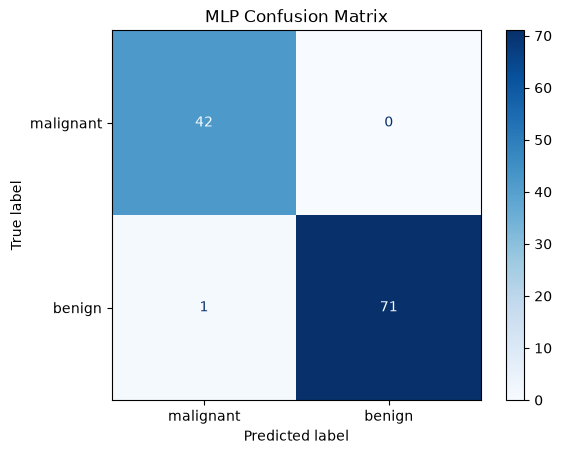

In [13]:
import matplotlib.pyplot as plt

cm = sklearn.metrics.confusion_matrix(y_test, y_pred)

disp = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cancer["target_names"])
disp.plot(cmap=plt.cm.Blues)

plt.title("MLP Confusion Matrix")
plt.show()

## Additional material

- A series of four videos on neural networks from the (generally) excellent channel [3Blue1Brown](https://www.youtube.com/@3blue1brown).

In [14]:
from IPython.display import YouTubeVideo

YouTubeVideo("aircAruvnKk?si=p7eKKqYI8u8mqfIb")